In [170]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset, WeightedRandomSampler
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from typing import Tuple
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.preprocessing import *

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


### Loading cifar-10 dataset

In [171]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="C:/Users/Emilien JEMELEN/Documents/CIFAR/cifar_data", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="C:/Users/Emilien JEMELEN/Documents/CIFAR/cifar_data", train=False, transform=transform, download=True)

# airplance = 1, not airplane = 0
binarize_labels(full_train_dataset)
binarize_labels(official_test_dataset)

In [172]:
full_train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [173]:
# Combine both datasets
combined_dataset = ConcatDataset([full_train_dataset, official_test_dataset])
# Total combined length
total_length = len(combined_dataset)
# Shuffle and split indices
indices = list(range(total_length))
rd.shuffle(indices)
# Split into train (for cnn training) and test (which will be training+test sets for Selective Prediction module)
train_indices = indices[:20000]
test_indices = indices[20000:]
# Create subsets
new_train_dataset = Subset(combined_dataset, train_indices)
new_test_dataset = Subset(combined_dataset, test_indices)
# get their associated labels from combined_dataset
train_labels = get_subset_labels(new_train_dataset, combined_dataset)
test_labels = get_subset_labels(new_test_dataset, combined_dataset)

# Create test dataloader (which will be training+test sets for Selective Prediction module)
test_loader = DataLoader(new_test_dataset, batch_size=6, shuffle=False)

# Create balanced samplers for training and validation of cnn
train_sampler = get_balanced_sampler(train_labels)
val_sampler = get_balanced_sampler(test_labels)
# Create DataLoaders using balanced samplers
train_loader = DataLoader(new_train_dataset, batch_size=6, sampler=train_sampler)
val_loader = DataLoader(new_test_dataset, batch_size=6, sampler=val_sampler)

## Training small CNN for cifar-2 classification task

In [174]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=20, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=32, kernel_size=4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))  # Force feature map to 4x4
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)             # Output shape: [B, 32, 4, 4]
        x = x.view(x.size(0), -1)             # Flatten safely: [B, 512]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model
cnn = SmallCNN().to(device)

In [52]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)
N_test = 1000

# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    cnn.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate cnn at the end of current epoch
    cnn.eval()
    correct = 0
    total = 0
    print('TESTING')
    c = 0
    with torch.no_grad():
        for images, labels in val_loader:
            if c == N_test:
                break
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            c += 1
            
    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(cnn.state_dict(), "C:/Users/Emilien JEMELEN/Documents/CIFAR/cnn_cifar_binary_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 3334/3334 [07:59<00:00,  6.95it/s]


Epoch [1/10], Loss: 0.5111
Train Accuracy: 75.62%
TESTING
Test Accuracy: 78.25%
TRAINING EPOCH 1


100%|██████████| 3334/3334 [08:54<00:00,  6.24it/s]


Epoch [2/10], Loss: 0.4508
Train Accuracy: 78.67%
TESTING
Test Accuracy: 78.52%
TRAINING EPOCH 2


...

Epoch [8/10], Loss: 0.3664
Train Accuracy: 83.78%
TESTING
Test Accuracy: 81.92%
TRAINING EPOCH 8


100%|██████████| 3334/3334 [08:52<00:00,  6.26it/s]


Epoch [9/10], Loss: 0.3613
Train Accuracy: 83.68%
TESTING
Test Accuracy: 80.78%
TRAINING EPOCH 9


100%|██████████| 3334/3334 [08:51<00:00,  6.27it/s]


Epoch [10/10], Loss: 0.3556
Train Accuracy: 84.14%
TESTING
Test Accuracy: 80.58%


### Retrieving Softmax Response, Predicted class and True class for all samples in CNN test set 

In [175]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/Emilien JEMELEN/Documents/SGR/models_weights/cnn_cifar_binary_epoch7.pth", map_location=torch.device('cpu'))
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [95]:
sgr_dico = prepare_sgr_dico(test_loader, model = cnn, device = device, T = 1)
sgr_set = pd.DataFrame(sgr_dico)
pickle.dump(sgr_set, open('sgr_set_cnn','wb'))

100%|██████████| 6667/6667 [06:40<00:00, 16.64it/s]


In [179]:
sgr_set.sort_values('kappa')

,y_true,y_pred,kappa
25763,0.0,0.0,0.500013
29113,0.0,1.0,0.500018
38375,0.0,1.0,0.500025
36456,1.0,0.0,0.500030
38218,0.0,0.0,0.500048
...,...,...,...
29589,0.0,0.0,0.999880
32033,0.0,0.0,0.999899
24420,0.0,0.0,0.999912
21166,0.0,0.0,0.999930


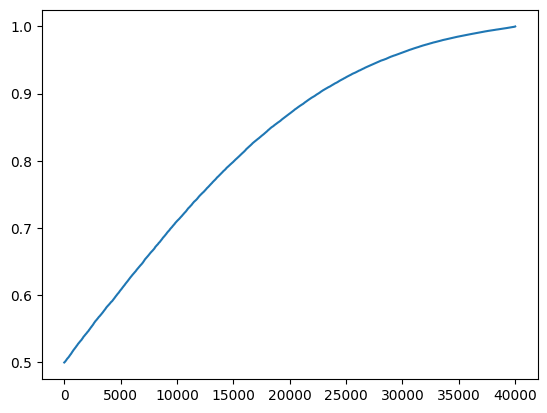

In [180]:
plt.plot(list(sgr_set.sort_values('kappa').kappa))
plt.show()

### Retrieving MC dropout binary entropy, Predicted class and True class for all samples in CNN test set 

In [178]:
sgr_set = pickle.load(open('sgr_set_cnn', 'rb'))

In [187]:
@torch.no_grad()
def mc_dropout_logits_variance_topclass(
    model, test_loader, device, T=50,
    p_dropout=0.5, use_unbiased_var=False
):
    """
    For each sample i:
      1) Compute T stochastic forward passes with dropout.
      2) Compute the mean logit over T for every class c.
      3) Let k_i = argmax_c mean_logit[i, c].
      4) Return the variance over T of logit[i, t, k_i] (and its mean).

    Returns:
        variances: [N] variance of the chosen (top) class logit per sample
        means:     [N] mean of the chosen (top) class logit per sample
        top_class: [N] index of the chosen class per sample
    """
    model = model.to(device)

    model.fc1 = nn.Sequential(nn.Dropout(p_dropout), model.fc1)

    # ---- Step 3: MC passes with ONLY dropout active; variance of top-class PROB ----
    model.eval()  # freeze everything
    # flip ONLY dropout to train to get stochasticity
    for m in model.modules():
        if isinstance(m, (nn.Dropout)):
            m.train()

    # Collect logits for all classes across T passes, kept on CPU
    per_pass = []  # each is [N, C]
    for _ in range(T):
        chunks = []
        for xb, _ in tqdm(test_loader):
            xb = xb.to(device, non_blocking=True)
            logits = model(xb).detach().cpu()   # [B, C]
            chunks.append(logits)
        per_pass.append(torch.cat(chunks, dim=0))  # [N, C]

    # Stack to [N, T, C]
    mat = torch.stack(per_pass, dim=0).permute(1, 0, 2).contiguous()  # [N, T, C]

    # Choose the most probable class per sample using mean logits (same argmax as mean probs)
    mean_logits = mat.mean(dim=1)                 # [N, C]
    top_class = mean_logits.argmax(dim=1)         # [N]

    # Gather the time-series of the chosen class for each sample -> [N, T]
    N, Tsize, C = mat.shape
    idx = top_class.view(N, 1, 1).expand(-1, Tsize, 1)  # [N, T, 1]
    chosen = mat.gather(dim=2, index=idx).squeeze(2)    # [N, T]

    # Compute mean and variance over T for that class
    means = chosen.mean(dim=1)                              # [N]
    variances = chosen.var(dim=1, unbiased=use_unbiased_var)  # [N]

    return variances, means, top_class

In [ ]:
variances, means, top_cls = mc_dropout_logits_variance_topclass(
    cnn, test_loader, device, T=30, p_dropout=0.2
    )

  8%|▊         | 546/6667 [00:35<06:54, 14.78it/s]

In [ ]:
MCD_res = {'variances': variances,
           'means': means,
           'top_cls': top_cls}
pickle.dump(MCD_res, open('MCD_res', 'wb'))

In [161]:
sgr_set['kappa'] = -MCD_res['variances'].numpy()

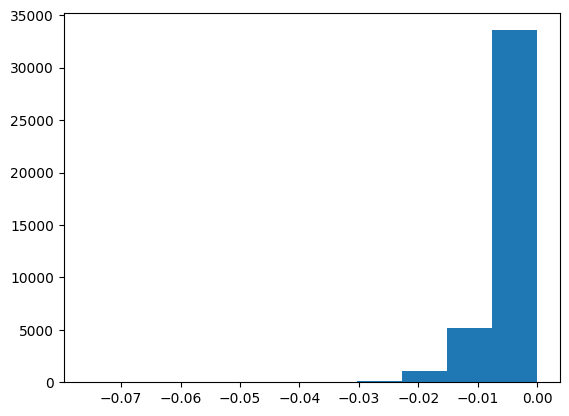

In [162]:
plt.hist(sgr_set['kappa'])
plt.show()

In [165]:
sgr_set.loc[sgr_set.kappa < -0.04].shape[0]

3

In [166]:
sgr_set = sgr_set.loc[sgr_set.kappa > -0.04] # discarding 3 outliers/abnormally distributed samples

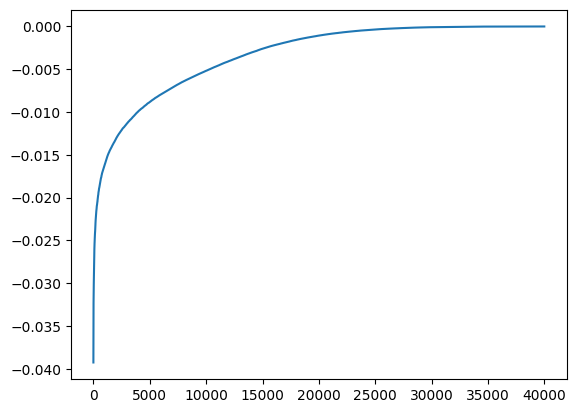

In [167]:
plt.plot(list(sgr_set.sort_values('kappa').kappa))

C:\Users\Emilien JEMELEN\AppData\Local\Temp\ipykernel_15188\3668081292.py:6: RuntimeWarning: invalid value encountered in scalar divide
  accuracies.append((df.y_pred==df.y_true).sum()/df.shape[0])


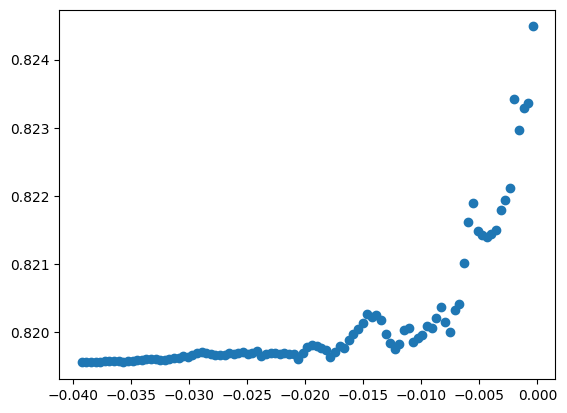

In [168]:
accuracies = []
kappas = np.linspace(sgr_set.sort_values('kappa').kappa.min(), sgr_set.sort_values('kappa').kappa.max(), num=100)

for thres in kappas:
    df = sgr_set.loc[sgr_set.kappa > thres].copy()
    accuracies.append((df.y_pred==df.y_true).sum()/df.shape[0])

plt.scatter(kappas, accuracies)
plt.show()

In [169]:
pickle.dump(sgr_set.reset_index(drop=True), open('sgr_set_cnn_MCD','wb'))